In [ ]:
!pip install recipe-scrapers beautifulsoup4 requests pandas tqdm pillow

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.2/307.2 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.5/97.5 kB 6.9 MB/s eta 0:00:00
  Created wheel for jstyleson: filename=jstyleson-0.0.2-py3-none-any.whl size=2383 sha256=f17aabebc38b13a11f75d37d462a793914ade9e1b6b557cdda5beb63cffb200a
  Stored in directory: /root/.cache/pip/wheels/13/7a/c7/3dd47109d94260d97a457d1ab4402f4b324af6f8e8b2aa7481
Successfully built jstyleson


In [ ]:
import requests, time
from bs4 import BeautifulSoup
from tqdm import tqdm

HEADERS = {"User-Agent": "Mozilla/5.0"}

def get_bbc_recipe_links(search_query, pages=30):
    links = set()

    for page in range(1, pages + 1):
        url = f"https://www.bbcgoodfood.com/search?q={search_query}&page={page}"
        r = requests.get(url, headers=HEADERS, timeout=20)

        print(search_query, page, r.status_code)

        if r.status_code != 200:
            continue

        soup = BeautifulSoup(r.text, "html.parser")

        for a in soup.find_all("a", href=True):
            href = a["href"]

            if "/recipes/" in href:
                if href.startswith("/"):
                    href = "https://www.bbcgoodfood.com" + href

                links.add(href.split("?")[0])

        time.sleep(0.5)

    return list(links)

queries = [
    "chicken", "beef", "fish", "salmon", "pasta",
    "rice", "cake", "salad", "soup", "seafood",
    "pizza", "bread", "dessert", "vegetarian", "curry"
]

bbc_links = []

for q in queries:
    bbc_links.extend(get_bbc_recipe_links(q, pages=30))

bbc_links = list(set(bbc_links))

print("Total links:", len(bbc_links))
bbc_links[:10]

chicken 1 200
chicken 2 200
chicken 3 200
chicken 4 200
chicken 5 200
chicken 6 200
chicken 7 200
chicken 8 200
chicken 9 200
chicken 10 200
chicken 11 200
chicken 12 200
chicken 13 200
chicken 14 200
chicken 15 200
chicken 16 200
chicken 17 200
chicken 18 200
chicken 19 200
chicken 20 200
chicken 21 200
chicken 22 200
chicken 23 200
chicken 24 200
chicken 25 200
chicken 26 200
chicken 27 200
chicken 28 200
chicken 29 200
chicken 30 200
beef 1 200
beef 2 200
beef 3 200
beef 4 200
beef 5 200
beef 6 200
beef 7 200
beef 8 200
beef 9 200
beef 10 200
beef 11 200
beef 12 200
beef 13 200
beef 14 200
beef 15 200
beef 16 200
beef 17 200
beef 18 200
beef 19 200
beef 20 200
beef 21 200
beef 22 200
beef 23 200
beef 24 200
beef 25 200
beef 26 200
beef 27 200
beef 28 200
beef 29 200
beef 30 200
fish 1 200
fish 2 200
fish 3 200
fish 4 200
fish 5 200
fish 6 200
fish 7 200
fish 8 200
fish 9 200
fish 10 200
fish 11 200
fish 12 200
fish 13 200
fish 14 200
fish 15 200
fish 16 200
fish 17 200
fish 18 200
f

['https://www.bbcgoodfood.com/recipes/beer-battered-pollock-bites',
 'https://www.bbcgoodfood.com/recipes/cooking-kids-spaghetti-meatballs-hidden-veg-sauce',
 'https://www.bbcgoodfood.com/recipes/smoked-mackerel-herb-beet-couscous',
 'https://www.bbcgoodfood.com/recipes/mussels-white-wine-sauce-garlic-butter-toasts',
 'https://www.bbcgoodfood.com/recipes/sag-aloo',
 'https://www.bbcgoodfood.com/recipes/cheese-ham-pea-risotto',
 'https://www.bbcgoodfood.com/recipes/spicy-roots',
 'https://www.bbcgoodfood.com/recipes/salmon-herb-blinis',
 'https://www.bbcgoodfood.com/recipes/chilli-honey-baked-ricotta-grapes-with-prosciutto',
 'https://www.bbcgoodfood.com/recipes/cranberry-sauce-port-star-anise']

In [ ]:
import os, re, json, time, requests
import pandas as pd
from bs4 import BeautifulSoup
from tqdm import tqdm

BASE_DIR = "/content/food_recipe_dataset"
IMG_DIR = f"{BASE_DIR}/images"
os.makedirs(IMG_DIR, exist_ok=True)

HEADERS = {"User-Agent": "Mozilla/5.0"}

def clean_text(x):
    return re.sub(r"\s+", " ", str(x)).strip()

def download_image(url, path):
    try:
        r = requests.get(url, headers=HEADERS, timeout=20)
        if r.status_code == 200 and len(r.content) > 1000:
            with open(path, "wb") as f:
                f.write(r.content)
            return True
    except:
        pass
    return False

def scrape_bbc(url, idx):
    try:
        r = requests.get(url, headers=HEADERS, timeout=20)
        soup = BeautifulSoup(r.text, "html.parser")

        title = soup.find("h1").get_text(strip=True) if soup.find("h1") else ""

        script_text = ""
        for script in soup.find_all("script"):
            txt = script.get_text()
            if "recipeIngredient" in txt:
                script_text = txt
                break

        if not script_text:
            return None

        og = soup.find("meta", property="og:image")
        image_url = og.get("content") if og else None

        ingredients_match = re.findall(r'"recipeIngredient"\s*:\s*\[(.*?)\]', script_text)
        ing_list = re.findall(r'"(.*?)"', ingredients_match[0]) if ingredients_match else []

        instructions = re.findall(r'"text"\s*:\s*"(.*?)"', script_text)
        instructions = [clean_text(x) for x in instructions if len(x) > 20]

        if not title or not ing_list or not instructions or not image_url:
            return None

        image_path = f"{IMG_DIR}/recipe_{idx}.jpg"
        if not download_image(image_url, image_path):
            return None

        return {
            "id": idx,
            "source": "BBC Good Food",
            "url": url,
            "title": clean_text(title),
            "ingredients": " | ".join([clean_text(x) for x in ing_list]),
            "instructions": " ".join(instructions[:10]),
            "image_url": image_url,
            "image_path": image_path
        }
    except:
        return None

all_recipes = []
seen_titles = set()

for url in tqdm(bbc_links):
    item = scrape_bbc(url, len(all_recipes))

    if item and item["title"].lower() not in seen_titles:
        all_recipes.append(item)
        seen_titles.add(item["title"].lower())

    time.sleep(0.5)

df = pd.DataFrame(all_recipes)

df.to_csv(f"{BASE_DIR}/recipes.csv", index=False)

with open(f"{BASE_DIR}/recipes.jsonl", "w", encoding="utf-8") as f:
    for item in all_recipes:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("Total collected:", len(df))
df.head()

100%|██████████| 7951/7951 [2:22:18<00:00,  1.07s/it]


Total collected: 7875


,id,source,url,title,ingredients,instructions,image_url,image_path
0,0,BBC Good Food,https://www.bbcgoodfood.com/recipes/beer-batte...,Beer-battered pollock bites,"400g pollock fillets, skinned and cut into bit...",First make the sauce by mixing all the ingredi...,https://images.immediate.co.uk/production/vola...,/content/food_recipe_dataset/images/recipe_0.jpg
1,1,BBC Good Food,https://www.bbcgoodfood.com/recipes/cooking-ki...,Cooking with kids: Spaghetti & meatballs with ...,300g good quality pork sausage (about 4 large ...,Children: Squeeze all the sausage meat out of ...,https://images.immediate.co.uk/production/vola...,/content/food_recipe_dataset/images/recipe_1.jpg
2,2,BBC Good Food,https://www.bbcgoodfood.com/recipes/smoked-mac...,Smoked mackerel with herb & beet couscous,100g couscous | 1 tsp horseradish sauce | 150g...,"Put the couscous into a large bowl, pour over ...",https://images.immediate.co.uk/production/vola...,/content/food_recipe_dataset/images/recipe_2.jpg
3,3,BBC Good Food,https://www.bbcgoodfood.com/recipes/mussels-wh...,Mussels in white wine sauce with garlic butter...,4 slices sourdough bread | 1 tbsp olive oil | ...,"First, make the garlic butter. Blitz all the i...",https://images.immediate.co.uk/production/vola...,/content/food_recipe_dataset/images/recipe_3.jpg
4,4,BBC Good Food,https://www.bbcgoodfood.com/recipes/sag-aloo,Saag aloo,2 tbsp sunflower oil | 1 onion finely chopped ...,"Heat 2 tbsp sunflower oil in a large pan, add ...",https://images.immediate.co.uk/production/vola...,/content/food_recipe_dataset/images/recipe_4.jpg


Total: 7875


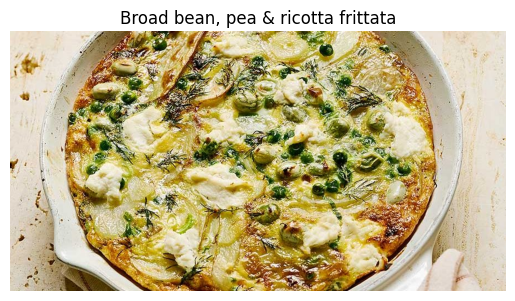

INGREDIENTS:
200g new potatoes thinly sliced | 1tbsp olive oil | 100g broad beans defrosted if using frozen | 100g peas defrosted if using frozen | 2 garlic cloves sliced | 3 spring onions sliced | 10g dill finely chopped | ½ lemon zested | 4 eggs | 2 tbsp milk | 25g ricotta | green salad to serve

DESCRIPTION:
Tip the sliced potatoes into a saucepan and cover with boiling water. Bring to a boil and cook for 3-5 mins until tender. Drain and set aside to steam-dry. Meanwhile, heat the oil in an ovenproof, non-stick frying pan over a medium-high heat. Fry the broad beans and peas for 2-3 mins until lightly golden, then add the potatoes, garlic and spring onions. Stir gently to combine and fry for a further 3-4 mins. Heat the grill to high. In a jug combine the dill, lemon zest, eggs and milk with some seasoning. Pour over the potatoes and quickly stir to ensure everything is well coated. Dot the ricotta over the top of the frittata and turn the heat to low. Cook for 3 mins until almost c

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

print("Total:", len(df))

sample = df.sample(1).iloc[0]
img = Image.open(sample["image_path"])

plt.imshow(img)
plt.axis("off")
plt.title(sample["title"])
plt.show()

print("INGREDIENTS:")
print(sample["ingredients"][:700])

print("\nDESCRIPTION:")
print(sample["instructions"][:700])

In [ ]:
!zip -r /content/food_recipe_dataset.zip /content/food_recipe_dataset

Streaming output truncated to the last 5000 lines.
  adding: content/food_recipe_dataset/images/recipe_1710.jpg (deflated 0%)
  adding: content/food_recipe_dataset/images/recipe_2611.jpg (deflated 1%)
  adding: content/food_recipe_dataset/images/recipe_4333.jpg (deflated 2%)
  adding: content/food_recipe_dataset/images/recipe_4614.jpg (deflated 2%)
  adding: content/food_recipe_dataset/images/recipe_1029.jpg (deflated 2%)
  adding: content/food_recipe_dataset/images/recipe_6585.jpg (deflated 1%)
  adding: content/food_recipe_dataset/images/recipe_7297.jpg (deflated 0%)
  adding: content/food_recipe_dataset/images/recipe_5992.jpg (deflated 0%)
  adding: content/food_recipe_dataset/images/recipe_4499.jpg (deflated 0%)
  adding: content/food_recipe_dataset/images/recipe_2752.jpg (deflated 0%)
  adding: content/food_recipe_dataset/images/recipe_4616.jpg (deflated 0%)
  adding: content/food_recipe_dataset/images/recipe_988.jpg (deflated 0%)
  adding: content/food_recipe_dataset/images/recip

In [ ]:
from google.colab import files
files.download("/content/food_recipe_dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import os
import re

csv_path = "/content/food_recipe_dataset/recipes.csv"

df = pd.read_csv(csv_path)

print("Before cleaning:", df.shape)
df.head()

Before cleaning: (7875, 8)


,id,source,url,title,ingredients,instructions,image_url,image_path
0,0,BBC Good Food,https://www.bbcgoodfood.com/recipes/beer-batte...,Beer-battered pollock bites,"400g pollock fillets, skinned and cut into bit...",First make the sauce by mixing all the ingredi...,https://images.immediate.co.uk/production/vola...,/content/food_recipe_dataset/images/recipe_0.jpg
1,1,BBC Good Food,https://www.bbcgoodfood.com/recipes/cooking-ki...,Cooking with kids: Spaghetti & meatballs with ...,300g good quality pork sausage (about 4 large ...,Children: Squeeze all the sausage meat out of ...,https://images.immediate.co.uk/production/vola...,/content/food_recipe_dataset/images/recipe_1.jpg
2,2,BBC Good Food,https://www.bbcgoodfood.com/recipes/smoked-mac...,Smoked mackerel with herb & beet couscous,100g couscous | 1 tsp horseradish sauce | 150g...,"Put the couscous into a large bowl, pour over ...",https://images.immediate.co.uk/production/vola...,/content/food_recipe_dataset/images/recipe_2.jpg
3,3,BBC Good Food,https://www.bbcgoodfood.com/recipes/mussels-wh...,Mussels in white wine sauce with garlic butter...,4 slices sourdough bread | 1 tbsp olive oil | ...,"First, make the garlic butter. Blitz all the i...",https://images.immediate.co.uk/production/vola...,/content/food_recipe_dataset/images/recipe_3.jpg
4,4,BBC Good Food,https://www.bbcgoodfood.com/recipes/sag-aloo,Saag aloo,2 tbsp sunflower oil | 1 onion finely chopped ...,"Heat 2 tbsp sunflower oil in a large pan, add ...",https://images.immediate.co.uk/production/vola...,/content/food_recipe_dataset/images/recipe_4.jpg


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# remove empty rows
df = df.dropna(subset=["title", "ingredients", "instructions", "image_path"])

# keep only existing images
df = df[df["image_path"].apply(os.path.exists)]

# clean columns
df["title_clean"] = df["title"].apply(clean_text)
df["ingredients_clean"] = df["ingredients"].apply(clean_text)
df["instructions_clean"] = df["instructions"].apply(clean_text)

# shorten text
df["ingredients_short"] = df["ingredients_clean"].apply(lambda x: " ".join(x.split()[:50]))
df["description_short"] = df["instructions_clean"].apply(lambda x: " ".join(x.split()[:40]))

# final target for RNN
df["target_text"] = (
    "startseq " +
    "title " + df["title_clean"] + " " +
    "ingredients " + df["ingredients_short"] + " " +
    "description " + df["description_short"] +
    " endseq"
)

df = df[df["target_text"].apply(lambda x: len(x.split()) > 10)]
df = df.reset_index(drop=True)

print("After cleaning:", df.shape)
df[["title", "ingredients_short", "description_short", "target_text"]].head()

After cleaning: (7875, 14)


,title,ingredients_short,description_short,target_text
0,Beer-battered pollock bites,400g pollock fillets skinned and cut into bite...,first make the sauce by mixing all the ingredi...,startseq title beer battered pollock bites ing...
1,Cooking with kids: Spaghetti & meatballs with ...,300g good quality pork sausage about 4 large o...,children squeeze all the sausage meat out of t...,startseq title cooking with kids spaghetti mea...
2,Smoked mackerel with herb & beet couscous,100g couscous 1 tsp horseradish sauce 150g pot...,put the couscous into a large bowl pour over 1...,startseq title smoked mackerel with herb beet ...
3,Mussels in white wine sauce with garlic butter...,4 slices sourdough bread 1 tbsp olive oil knob...,first make the garlic butter blitz all the ing...,startseq title mussels in white wine sauce wit...
4,Saag aloo,2 tbsp sunflower oil 1 onion finely chopped 2 ...,heat 2 tbsp sunflower oil in a large pan add 1...,startseq title saag aloo ingredients 2 tbsp su...


In [ ]:
cleaned_path = "/content/food_recipe_dataset/recipes_cleaned.csv"
df.to_csv(cleaned_path, index=False)

print("Saved:", cleaned_path)
print("Final rows:", len(df))

Saved: /content/food_recipe_dataset/recipes_cleaned.csv
Final rows: 7875


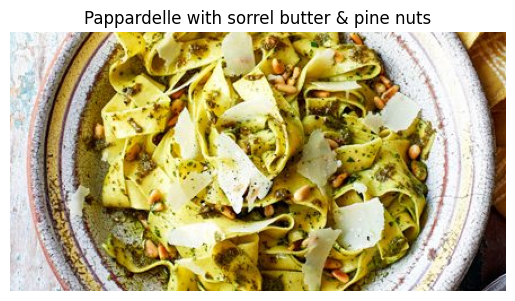

TARGET TEXT:
startseq title pappardelle with sorrel butter pine nuts ingredients 2 large handfuls sorrel leaves 100g butter softened lemon juiced 250g pappardelle pasta 75g toasted pine nuts to serve parmesan shaved to serve description roughly chop the sorrel tip into a food processor with the butter and lemon juice and whizz to a paste season scrape onto a sheet of cling film and roll into a log will keep in the fridge for one endseq


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

sample = df.sample(1).iloc[0]

img = Image.open(sample["image_path"])
plt.imshow(img)
plt.axis("off")
plt.title(sample["title"])
plt.show()

print("TARGET TEXT:")
print(sample["target_text"])

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 6300
Val: 787
Test: 788


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

MAX_WORDS = 10000
MAX_LEN = 80

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="oov")
tokenizer.fit_on_texts(train_df["target_text"])

x_train_text = pad_sequences(
    tokenizer.texts_to_sequences(train_df["target_text"]),
    maxlen=MAX_LEN,
    padding="post"
)

x_val_text = pad_sequences(
    tokenizer.texts_to_sequences(val_df["target_text"]),
    maxlen=MAX_LEN,
    padding="post"
)

x_test_text = pad_sequences(
    tokenizer.texts_to_sequences(test_df["target_text"]),
    maxlen=MAX_LEN,
    padding="post"
)

y_train = np.zeros_like(x_train_text)
y_train[:, :-1] = x_train_text[:, 1:]

y_val = np.zeros_like(x_val_text)
y_val[:, :-1] = x_val_text[:, 1:]

y_test = np.zeros_like(x_test_text)
y_test[:, :-1] = x_test_text[:, 1:]

print(x_train_text.shape, y_train.shape)

(6300, 80) (6300, 80)


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm

IMG_SIZE = 224

resnet = ResNet50(weights="imagenet", include_top=False, pooling="avg")

def extract_features(image_paths):
    features = []

    for path in tqdm(image_paths):
        try:
            img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
            arr = img_to_array(img)
            arr = np.expand_dims(arr, axis=0)
            arr = preprocess_input(arr)

            feat = resnet.predict(arr, verbose=0)
            features.append(feat[0])
        except:
            features.append(np.zeros(2048))

    return np.array(features)

x_train_img = extract_features(train_df["image_path"].values)
x_val_img = extract_features(val_df["image_path"].values)
x_test_img = extract_features(test_df["image_path"].values)

print(x_train_img.shape)
print(x_val_img.shape)
print(x_test_img.shape)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


 98%|█████████▊| 773/787 [04:38<00:03,  3.52it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 788/788 [04:36<00:00,  2.86it/s]

(6300, 2048)
(787, 2048)
(788, 2048)
